# Synthetic Ground-Truth Training — Multi-Trace

Like the single-trace synthetic experiment, but trains against **multiple ground-truth
traces simultaneously**, each generated with the same AdEx parameters but a different
step-current amplitude (e.g. 300, 350, …, 600 pA).

**Idea:** A single stimulus probes only a slice of the parameter manifold. Local minima
generally don't coincide across stimulation regimes, so summing per-trace losses tends
to reinforce shared descent directions while smoothing out trace-specific spurious minima.
This does not fix the loss landscape itself — if Guarino plateaus on every trace, the
average still plateaus — but it should help when the landscape's pathologies are
stimulus-dependent.

**Setup:**
- Ground truth parameters: Naud "tonic" set
- Multiple synthetic step currents at different amplitudes
- Initial parameters: small perturbation (~20%) from ground truth
- Combined loss: mean of per-trace Guarino losses (gradient averaging is automatic)

In [12]:
import logging

import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np
from jax import config

from ADoptEX.core.data import TraceData, crop_to_stim_window, detect_spikes, load_trace
from ADoptEX.core.parameters import DEFAULT_PARAMS, NAUD_PARAMETERS, PARAM_BOUNDS
from ADoptEX.core.simulation import simulate_with_current_trace
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import (
    GuarinoFeatures,
    GuarinoLossConfig,
    VanRossumLossConfig,
    extract_experimental_features,
    guarino_loss,
    make_guarino_loss_fn,
    make_van_rossum_loss_fn,
    spike_train_from_voltage,
)
from ADoptEX.plotting import (
    fit_before_after_plot,
    fit_comparison_plot,
    parameter_comparison_plot,
    spike_timing_plot,
    trace_plot,
    trace_stim_window_plot,
    training_comparison_plot,
    training_history_plot,
)
from ADoptEX.training import TrainingResult
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell, train

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

SEED = 42

## 1. Ground Truth Parameters & Current Stimuli

Build a list of synthetic step-current waveforms at different amplitudes. The same
ground-truth AdEx parameters drive each one, producing distinct voltage traces that
together probe a wider region of the parameter manifold than any single trace.

In [13]:
# --- Synthetic step-current waveforms at multiple amplitudes ---
dt_ms = 0.025
t_max_ms = 100.0
stim_delay_ms = 5.0
stim_duration_ms = 95.0

# Sweep over stimulus amplitudes — each yields one ground-truth trace.
STIM_CURRENTS_PA 350.0, 400.0, 450.0, 500.0, 550.0, 600.0]

n_samples = int(round(t_max_ms / dt_ms))
time_arr = np.arange(n_samples) * dt_ms
stim_start_idx = int(round(stim_delay_ms / dt_ms))
stim_end_idx = int(round((stim_delay_ms + stim_duration_ms) / dt_ms))

def make_current_trace(amp_pa: float) -> TraceData:
    current = np.zeros(n_samples)
    current[stim_start_idx:stim_end_idx] = amp_pa
    return TraceData(
        time=time_arr,
        voltage=np.zeros(n_samples),  # placeholder
        current=current,
        dt_ms=dt_ms,
        spike_times=np.array([]),
        stim_start_idx=stim_start_idx,
        stim_end_idx=stim_end_idx,
        stim_current_pA=float(amp_pa),
    )

current_traces = [make_current_trace(a) for a in STIM_CURRENTS_PA]
N_TRACES = len(current_traces)

print(f"Built {N_TRACES} current traces ({n_samples} samples, dt={dt_ms:.3f} ms)")
print(f"Stim window: idx {stim_start_idx} - {stim_end_idx} ({stim_duration_ms:.1f} ms)")
print(f"Amplitudes: {STIM_CURRENTS_PA} pA")

Built 6 current traces (4000 samples, dt=0.025 ms)
Stim window: idx 200 - 4000 (95.0 ms)
Amplitudes: [350.0, 400.0, 450.0, 500.0, 550.0, 600.0] pA


In [14]:
# --- Ground truth parameters (change this to test different regimes) ---
GROUND_TRUTH_BASE = "tonic"  # "tonic", "adaptation", or "original"

ground_truth_params = dict(NAUD_PARAMETERS[GROUND_TRUTH_BASE])
# ground_truth_params["v_threshold"] = 0.0
# ground_truth_params["delta_T"] = 3.0

# Override values that would sit at parameter bounds (which prevents perturbation
# and makes recovery trivial/impossible). Choose values well inside PARAM_BOUNDS.
# ground_truth_params["v_reset"] = -58.0   # bounds: [-60, -45], midpoint -52.5
# ground_truth_params["E_L"] = -72.0       # bounds: [-75, -68], midpoint -71.5
# ground_truth_params["v_T"] = -45.0       # bounds: [-60, -30], well inside
# ground_truth_params["tau_w"] = 200.0     # bounds: [20, 320], well inside

print(f"Ground truth base: {GROUND_TRUTH_BASE}")
print("Ground truth parameters:")
for k, v in ground_truth_params.items():
    bounds = PARAM_BOUNDS.get(k)
    if bounds:
        pos = (v - bounds.min) / (bounds.max - bounds.min) * 100
        print(f"  {k:<12} {v:>10.3f}  [{bounds.min}, {bounds.max}]  ({pos:.0f}% into range)")
    else:
        print(f"  {k:<12} {v:>10.3f}")

Ground truth base: tonic
Ground truth parameters:
  C_m             200.000  [10.0, 240.0]  (83% into range)
  g_L              10.000  [6.0, 14.0]  (50% into range)
  E_L             -70.000  [-110.0, -65.0]  (89% into range)
  v_T             -50.000  [-60.0, -35.0]  (40% into range)
  delta_T           2.000  [1, 20.0]  (5% into range)
  v_reset         -58.000  [-80.0, -45.0]  (63% into range)
  v_threshold       0.000  [-20.0, 30.0]  (40% into range)
  tau_w            30.000  [20.0, 320.0]  (3% into range)
  a                 2.000  [-5.0, 5.0]  (70% into range)
  b                 0.000  [0.0, 65.0]  (0% into range)
  I               500.000


## 2. Generate Synthetic Voltage Traces

Simulate each current with the same ground-truth parameters. Each result is wrapped
as a `TraceData` (same structure as experimental data) and collected into a list.

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
 Stim (pA)  #spikes  rate (Hz)
------------------------------
       350        5 

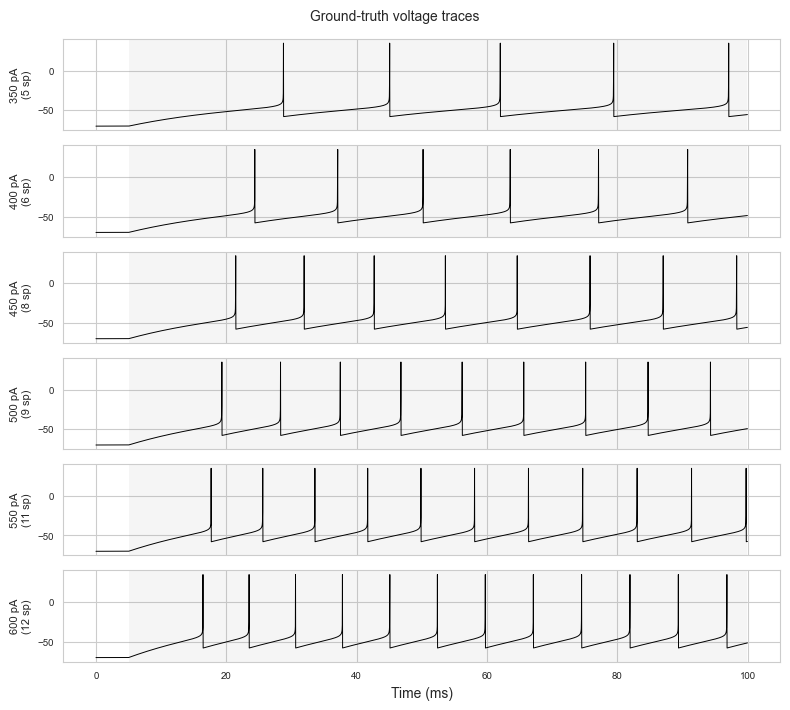

In [15]:
SPIKE_PEAK_MV = 35.0

def simulate_ground_truth(current_trace: TraceData) -> TraceData:
    sim = simulate_with_current_trace(
        params=ground_truth_params,
        current_trace_pA=current_trace.current,
        dt_ms=current_trace.dt_ms,
        use_surrogate=False,
    )
    n = len(current_trace.time)
    voltage_gt = sim.voltage[:n].copy()
    # Inject spike peaks (Jaxley resets within timestep, so peaks aren't recorded).
    for st in sim.spike_times:
        idx = int(st / current_trace.dt_ms)
        if 0 <= idx < len(voltage_gt):
            voltage_gt[idx] = SPIKE_PEAK_MV
    return TraceData(
        time=current_trace.time,
        voltage=voltage_gt,
        current=current_trace.current,
        dt_ms=current_trace.dt_ms,
        spike_times=sim.spike_times,
        stim_start_idx=current_trace.stim_start_idx,
        stim_end_idx=current_trace.stim_end_idx,
        stim_current_pA=current_trace.stim_current_pA,
    )

datas = [simulate_ground_truth(c) for c in current_traces]

print(f"{'Stim (pA)':>10} {'#spikes':>8} {'rate (Hz)':>10}")
print("-" * 30)
for d in datas:
    rate_hz = d.n_spikes / (d.stim_duration_ms / 1000.0)
    print(f"{d.stim_current_pA:>10.0f} {d.n_spikes:>8d} {rate_hz:>10.1f}")

# Quick visual: stack all GT traces.
import matplotlib.pyplot as plt
fig, axes = plt.subplots(N_TRACES, 1, figsize=(8, 1.2 * N_TRACES), sharex=True)
for ax, d in zip(axes, datas):
    ax.plot(d.time, d.voltage, color="k", lw=0.7)
    ax.axvspan(d.time[d.stim_start_idx], d.time[min(d.stim_end_idx, len(d.time)-1)],
               color="grey", alpha=0.08, lw=0)
    ax.set_ylabel(f"{d.stim_current_pA:.0f} pA\n({d.n_spikes} sp)", fontsize=8)
    ax.tick_params(labelsize=7)
axes[-1].set_xlabel("Time (ms)")
fig.suptitle("Ground-truth voltage traces", fontsize=10)
fig.tight_layout();

## 3. Perturbed Initial Parameters

Create initial parameters by adding ~15% noise to the ground truth.
This simulates the real scenario where we don't know the true values.

In [16]:
PERTURBATION = 0.2 # relative perturbation

# C_m, g_L, E_L, v_T, delta_T, v_reset, v_threshold, tau_w, a, b
# TRAINABLE_STAGE1 = ["C_m", "g_L", "v_reset", "v_T", "E_L", "delta_T", "tau_w", "a", "b"]

# Good:
# TRAINABLE_STAGE1 = ["C_m"] # good with lr 0.05
# TRAINABLE_STAGE1 = ["g_L"] # good with learning rate 0.05 and only that
# TRAINABLE_STAGE1 = ["v_reset"] # good with lr 0.05
# TRAINABLE_STAGE1 = ["v_T"] # good with learning rate 0.05 and 0.1
# TRAINABLE_STAGE1 = ["E_L"] # somewhat with lr 0.05
# TRAINABLE_STAGE1 = ["delta_T"] # good with lr 0.05

TRAINABLE_STAGE1 = ["C_m", "g_L", "v_reset", "v_T", "E_L", "delta_T"] # works somewhat well-ish, depending on perturbation

# Bad:
# TRAINABLE_STAGE1 = ["tau_w"] # no gradient information, in isolation doesn't do anything
# TRAINABLE_STAGE1 = ["a"] # no gradient information
# TRAINABLE_STAGE1 = ["b"] # no gradient information

def perturb_params(
    params: dict,
    trainable: list[str],
    perturbation: float,
    key: jax.Array,
) -> dict:
    """Add relative noise to trainable params, clipping to PARAM_BOUNDS."""
    perturbed = dict(params)
    keys = jr.split(key, len(trainable))
    for k, name in zip(keys, trainable):
        val = params[name]
        bounds = PARAM_BOUNDS[name]
        # Scale noise by parameter range to handle params near zero (e.g. a=0)
        param_range = bounds.max - bounds.min
        noise = float(jr.uniform(k, minval=-perturbation, maxval=perturbation))
        perturbed[name] = bounds.clip(val + noise * param_range)
    return perturbed


all_trainable = list(set(TRAINABLE_STAGE1))
initial_params = perturb_params(
    ground_truth_params, all_trainable, PERTURBATION, jr.PRNGKey(SEED)
)


#initial_params["C_m"] = 70
#initial_params["g_L"] = 8.4
#initial_params["E_L"] = -73
#initial_params["v_T"] = -58
#initial_params["delta_T"] = 12
#initial_params["v_reset"] = -55
# initial_params = ground_truth_params.copy()

print(f"{'Parameter':<12} {'Ground Truth':>12} {'Initial':>12} {'Error':>8}")
print("-" * 48)
for k in all_trainable:
    gt = ground_truth_params[k]
    init = initial_params[k]
    bounds = PARAM_BOUNDS[k]
    err_pct = abs(init - gt) / (bounds.max - bounds.min) * 100
    print(f"{k:<12} {gt:>12.3f} {init:>12.3f} {err_pct:>7.1f}%")

Parameter    Ground Truth      Initial    Error
------------------------------------------------
delta_T             2.000        2.230     1.2%
v_T               -50.000      -47.723     9.1%
v_reset           -58.000      -55.659     6.7%
C_m               200.000      189.789     4.4%
g_L                10.000       10.780     9.7%
E_L               -70.000      -71.543     3.4%


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
 Stim (pA)   init #sp   gt #sp    gamma
----------------------------------------
 

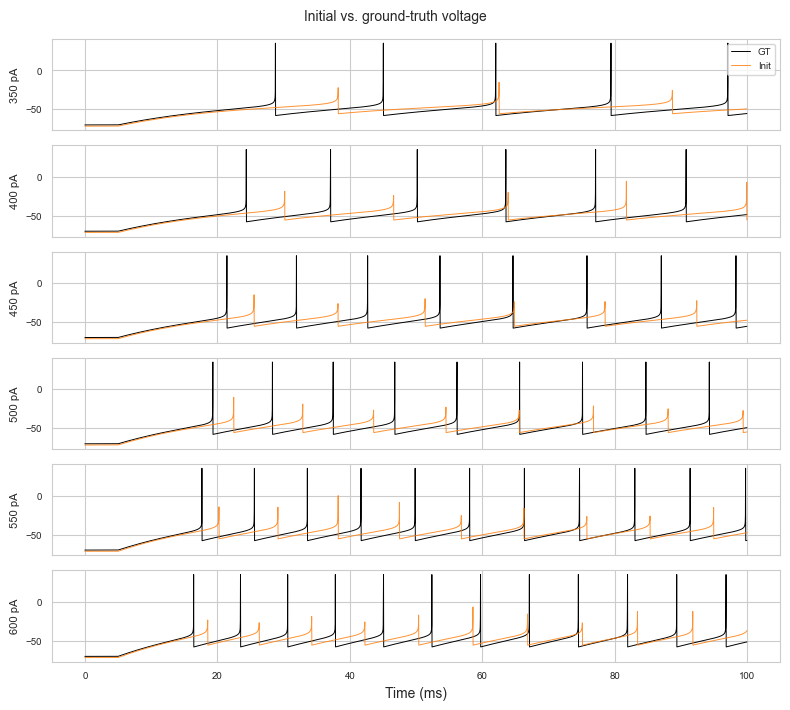

In [17]:
# Simulate all traces with the perturbed initial parameters to see the starting point.
sims_init = [
    simulate_with_current_trace(
        params=initial_params,
        current_trace_pA=d.current,
        dt_ms=d.dt_ms,
        use_surrogate=False,
    )
    for d in datas
]

cfs_init = []
print(f"{'Stim (pA)':>10} {'init #sp':>10} {'gt #sp':>8} {'gamma':>8}")
print("-" * 40)
for d, s in zip(datas, sims_init):
    if s.n_spikes > 0 and d.n_spikes > 0:
        cf = coincidence_factor(
            spike_times_data=d.spike_times,
            spike_times_model=s.spike_times,
            duration_ms=d.stim_duration_ms,
            delta_ms=2,
        )
        cfs_init.append(cf)
        gamma_str = f"{cf.gamma:.3f}"
    else:
        cfs_init.append(None)
        gamma_str = "  N/A"
    print(f"{d.stim_current_pA:>10.0f} {s.n_spikes:>10d} {d.n_spikes:>8d} {gamma_str:>8}")

# Stacked init-vs-gt overlay
fig, axes = plt.subplots(N_TRACES, 1, figsize=(8, 1.2 * N_TRACES), sharex=True)
for ax, d, s in zip(axes, datas, sims_init):
    n = min(len(d.time), len(s.time))
    ax.plot(d.time[:n], d.voltage[:n], color="k", lw=0.7, label="GT")
    ax.plot(d.time[:n], s.voltage[:n], color="tab:orange", lw=0.7, alpha=0.85, label="Init")
    ax.set_ylabel(f"{d.stim_current_pA:.0f} pA", fontsize=8)
    ax.tick_params(labelsize=7)
axes[0].legend(fontsize=7, loc="upper right")
axes[-1].set_xlabel("Time (ms)")
fig.suptitle("Initial vs. ground-truth voltage", fontsize=10)
fig.tight_layout();

In [18]:
# --- Loss floors at ground truth: per-trace + combined (mean) ---
_config_gt = TrainingConfig(
    surrogate_type="superspike", surrogate_slope=2.0, clip_to_bounds=True,
)

_floor_per_trace = []
for d in datas:
    _cell, _stim, _tmax, _params = setup_trainable_cell(
        initial_params=ground_truth_params,
        current_trace_pA=d.current,
        dt_ms=d.dt_ms,
        config=_config_gt,
        trainable_params=TRAINABLE_STAGE1,
    )
    _exp_features = extract_experimental_features(
        voltage_trace=d.voltage,
        dt_ms=d.dt_ms,
        stim_duration_ms=d.stim_duration_ms,
        stim_end_index=d.stim_end_idx,
    )
    _loss_fn = make_guarino_loss_fn(
        cell=_cell, data_stimuli=_stim, t_max=_tmax, dt_ms=d.dt_ms,
        exp_features=_exp_features, stim_duration_ms=d.stim_duration_ms,
        stim_end_index=d.stim_end_idx,
        loss_config=GuarinoLossConfig(),
    )
    _floor_per_trace.append(float(_loss_fn(_params)))

loss_floor_combined = float(np.mean(_floor_per_trace))

print("Per-trace Guarino loss at ground truth:")
for d, fl in zip(datas, _floor_per_trace):
    print(f"  {d.stim_current_pA:>5.0f} pA -> {fl:.4f}")
print(f"Combined (mean) loss floor: {loss_floor_combined:.4f}")

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 

## 4. Multi-Trace Guarino Training

Build one cell + Guarino loss closure per stimulus amplitude. The combined loss is
the mean over per-trace losses; `jax.value_and_grad` then averages the gradients
automatically. Training is otherwise identical to the single-trace version.

In [19]:
# --- Training config ---
training_config = TrainingConfig(
    optimizer="polyak",
    learning_rate=0.001,
    n_epochs=50,
    surrogate_type="superspike",
    surrogate_slope=5.0,
    print_every=1,
    polyak_alpha=1.0,
    polyak_beta=0.8,
    clip_to_bounds=False,
    use_param_transform=True,
    verbose=True,
    return_best=True,
)

# --- Build one trainable cell + per-trace Guarino loss for each stimulus ---
# Each cell registers the same trainable parameters with the same initial values,
# so the trainable-params lists are numerically identical — we only keep one.
trace_loss_fns = []
trainable_params_shared = None
cells = []
for d in datas:
    cell_i, stim_i, tmax_i, params_i = setup_trainable_cell(
        initial_params=initial_params,
        current_trace_pA=d.current,
        dt_ms=d.dt_ms,
        config=training_config,
        trainable_params=TRAINABLE_STAGE1,
    )
    exp_features_i = extract_experimental_features(
        voltage_trace=jnp.array(d.voltage),
        dt_ms=d.dt_ms,
        stim_duration_ms=d.stim_duration_ms,
        stim_end_index=d.stim_end_idx,
    )
    loss_fn_i = make_guarino_loss_fn(
        cell=cell_i,
        data_stimuli=stim_i,
        t_max=tmax_i,
        dt_ms=d.dt_ms,
        exp_features=exp_features_i,
        stim_duration_ms=d.stim_duration_ms,
        stim_end_index=d.stim_end_idx,
        loss_config=GuarinoLossConfig(weight_spike_count=0.1),
        temperature=0.2,
        beta=5,
        validity_beta=5,
    )
    trace_loss_fns.append(loss_fn_i)
    cells.append(cell_i)
    if trainable_params_shared is None:
        trainable_params_shared = params_i

# Combined loss: mean over per-trace Guarino losses.
# JAX traces through the sum; gradients are averaged over the batch of stimuli.
def combined_loss_fn(params):
    return sum(fn(params) for fn in trace_loss_fns) / len(trace_loss_fns)

initial_combined = float(combined_loss_fn(trainable_params_shared))
print(f"Initial per-trace Guarino losses:")
for d, fn in zip(datas, trace_loss_fns):
    print(f"  {d.stim_current_pA:>5.0f} pA -> {float(fn(trainable_params_shared)):.4f}")
print(f"Initial combined (mean) loss: {initial_combined:.4f}")

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 

In [20]:
result_stage1 = train(
    loss_fn=combined_loss_fn,
    trainable_params=trainable_params_shared,
    config=training_config,
    initial_params=initial_params,
)

print(f"\nMulti-trace training complete.")
print(f"  Best loss:   {result_stage1.best_loss:.4f}")
print(f"  Total time:  {result_stage1.total_time:.1f} s")
print(f"  Per-epoch:   {result_stage1.mean_time_per_epoch * 1000:.1f} ms (over {N_TRACES} traces)")

Training: optimizer=polyak lr=0.001 epochs=50 surrogate=superspike slope=5.0 alpha=1.0 beta=0.8 sigmoid_transform
Epoch    0 | loss=1.774469 | grad_norm=7.22e+04 | lr=1.77e-03 | C_m=190.0336, g_L=10.7769, v_reset=-55.5496, v_T=-47.7481, E_L=-71.5490, delta_T=2.2308
Epoch    1 | loss=1.648429 | grad_norm=6.33e+04 | lr=1.65e-03 | C_m=189.8358, g_L=10.7704, v_reset=-55.5517, v_T=-47.8173, E_L=-71.5045, delta_T=2.2288
Epoch    2 | loss=1.591023 | grad_norm=1.13e+06 | lr=1.59e-03 | C_m=190.0081, g_L=10.7716, v_reset=-55.3764, v_T=-47.8575, E_L=-71.5346, delta_T=2.2258
Epoch    3 | loss=1.554813 | grad_norm=1.12e+07 | lr=1.55e-03 | C_m=189.3562, g_L=10.7651, v_reset=-55.6106, v_T=-47.8963, E_L=-71.4464, delta_T=2.2240
Epoch    4 | loss=1.530369 | grad_norm=6.96e+03 | lr=1.53e-03 | C_m=189.5260, g_L=10.7675, v_reset=-55.6083, v_T=-47.8559, E_L=-71.4680, delta_T=2.2261
Epoch    5 | loss=1.562386 | grad_norm=3.14e+03 | lr=1.56e-03 | C_m=189.6614, g_L=10.7700, v_reset=-55.6080, v_T=-47.8201, E_L


Multi-trace training complete.
  Best loss:   0.2415
  Total time:  3.5 s
  Per-epoch:   70.1 ms (over 6 traces)


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
 Stim (pA)   final #sp   gt #sp    gamma
----------------------------------------


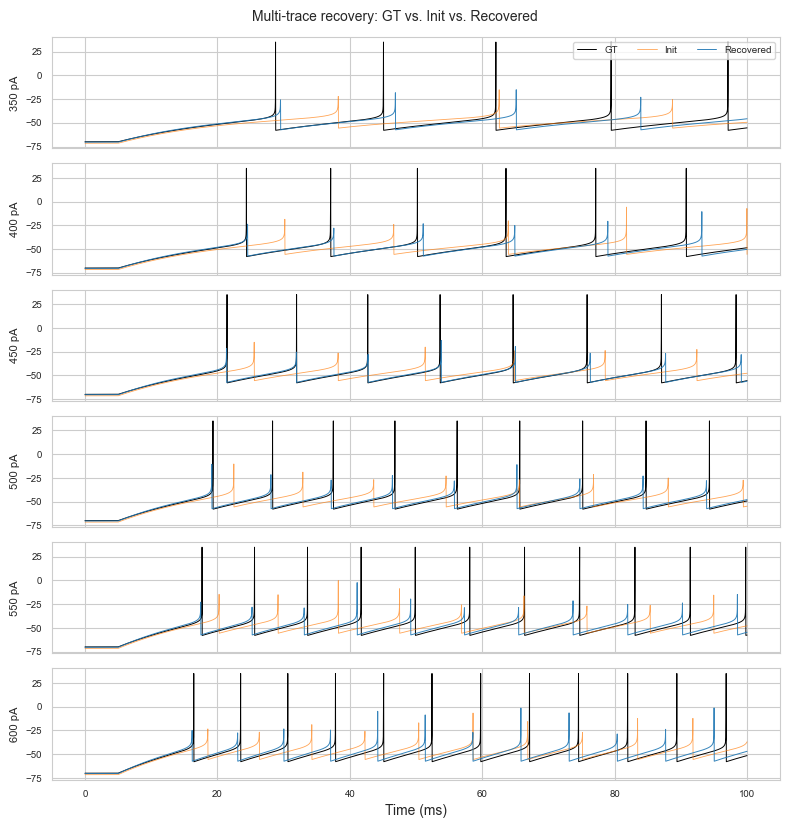

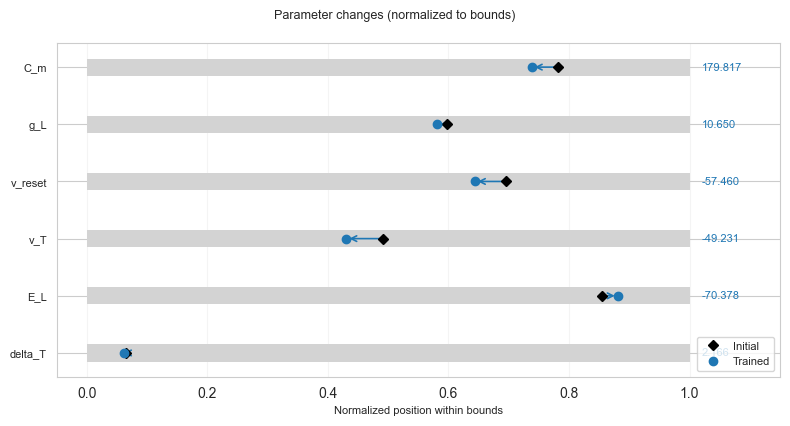

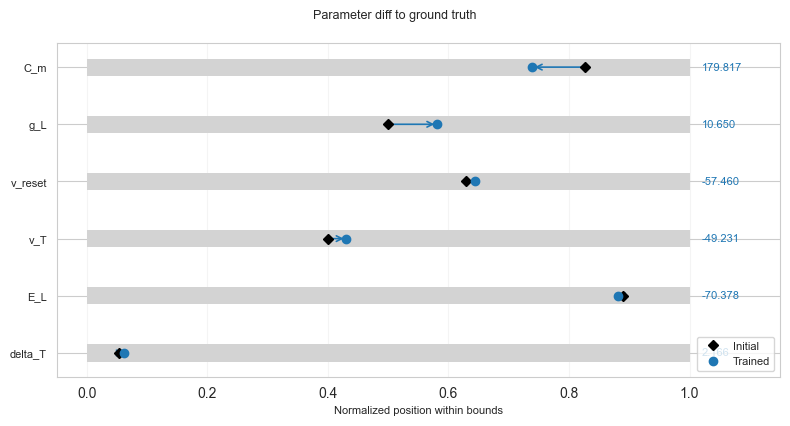

In [21]:
# --- Evaluate trained parameters across all traces ---
params_after = dict(initial_params)
params_after.update(result_stage1.get_params_dict())

sims_after = [
    simulate_with_current_trace(
        params=params_after,
        current_trace_pA=d.current,
        dt_ms=d.dt_ms,
        use_surrogate=False,
    )
    for d in datas
]

cfs_after = []
print(f"{'Stim (pA)':>10} {'final #sp':>11} {'gt #sp':>8} {'gamma':>8}")
print("-" * 40)
for d, s in zip(datas, sims_after):
    if s.n_spikes > 0 and d.n_spikes > 0:
        cf = coincidence_factor(
            spike_times_data=d.spike_times,
            spike_times_model=s.spike_times,
            duration_ms=d.stim_duration_ms,
            delta_ms=2,
        )
        cfs_after.append(cf)
        gamma_str = f"{cf.gamma:.3f}"
    else:
        cfs_after.append(None)
        gamma_str = "  N/A"
    print(f"{d.stim_current_pA:>10.0f} {s.n_spikes:>11d} {d.n_spikes:>8d} {gamma_str:>8}")

mean_gamma = np.mean([cf.gamma for cf in cfs_after if cf is not None]) if any(cf is not None for cf in cfs_after) else float("nan")
print(f"\nMean gamma across traces: {mean_gamma:.3f}")

# Stacked GT / Init / Recovered overlay
fig, axes = plt.subplots(N_TRACES, 1, figsize=(8, 1.4 * N_TRACES), sharex=True)
for ax, d, si, sf in zip(axes, datas, sims_init, sims_after):
    n = min(len(d.time), len(si.time), len(sf.time))
    ax.plot(d.time[:n], d.voltage[:n], color="k", lw=0.7, label="GT")
    ax.plot(d.time[:n], si.voltage[:n], color="tab:orange", lw=0.6, alpha=0.7, label="Init")
    ax.plot(d.time[:n], sf.voltage[:n], color="tab:blue", lw=0.7, alpha=0.9, label="Recovered")
    ax.set_ylabel(f"{d.stim_current_pA:.0f} pA", fontsize=8)
    ax.tick_params(labelsize=7)
axes[0].legend(fontsize=7, loc="upper right", ncol=3)
axes[-1].set_xlabel("Time (ms)")
fig.suptitle("Multi-trace recovery: GT vs. Init vs. Recovered", fontsize=10)
fig.tight_layout()

# Parameter recovery vs ground truth
parameter_comparison_plot(result_stage1)
parameter_comparison_plot(TrainingResult(
    trainable_params=result_stage1.trainable_params,
    loss_history=result_stage1.loss_history,
    time_per_epoch=result_stage1.time_per_epoch,
    config=result_stage1.config,
    initial_params=ground_truth_params,
), figtitle="Parameter diff to ground truth");

## 5. Publication Figure — Multi-Trace Recovery Summary

Composite thesis figure: stacked voltage overlays (GT vs. init vs. recovered) for each
stimulus amplitude, training-loss curve (combined loss), and per-parameter recovery error.

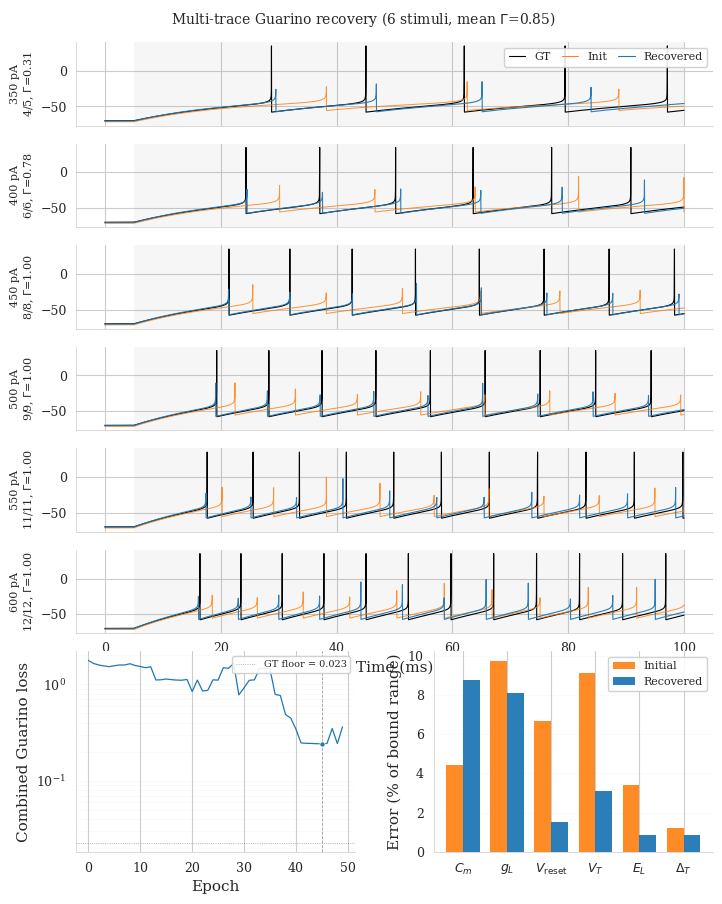

Saved guarino_multitrace_synthetic_recovery.pdf


In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

LOSS_NAME = "Guarino"
OUTPUT_PDF = f"{LOSS_NAME.lower()}_multitrace_synthetic_recovery.pdf"

GT_COLOR = "k"
INIT_COLOR = "tab:orange"
TRAINED_COLOR = "tab:blue"

PARAM_LABELS_TEX = {
    "C_m": r"$C_m$", "g_L": r"$g_L$", "E_L": r"$E_L$", "v_T": r"$V_T$",
    "delta_T": r"$\Delta_T$", "v_reset": r"$V_\mathrm{reset}$",
    "v_threshold": r"$V_\mathrm{th}$", "tau_w": r"$\tau_w$",
    "a": r"$a$", "b": r"$b$",
}

trainable = list(TRAINABLE_STAGE1)
init_err = [abs(initial_params[k] - ground_truth_params[k]) /
            (PARAM_BOUNDS[k].max - PARAM_BOUNDS[k].min) * 100 for k in trainable]
final_err = [abs(params_after[k] - ground_truth_params[k]) /
             (PARAM_BOUNDS[k].max - PARAM_BOUNDS[k].min) * 100 for k in trainable]

with plt.rc_context({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.6,
    "lines.linewidth": 0.9,
}):
    fig = plt.figure(figsize=(7.2, 0.8 * N_TRACES + 3.0))
    outer = gridspec.GridSpec(
        2, 1,
        height_ratios=[0.85 * N_TRACES, 1.8],
        hspace=0.32,
        left=0.10, right=0.985, top=0.96, bottom=0.08,
    )
    top_gs = outer[0].subgridspec(N_TRACES, 1, hspace=0.18)
    bottom_gs = outer[1].subgridspec(1, 2, wspace=0.55)

    # Per-trace voltage overlays (one row each)
    ax_first = None
    for i, (d, si, sf, cf) in enumerate(zip(datas, sims_init, sims_after, cfs_after)):
        ax = fig.add_subplot(top_gs[i], sharex=ax_first)
        if ax_first is None:
            ax_first = ax
        n = min(len(d.time), len(si.time), len(sf.time))
        t = d.time[:n]
        ax.axvspan(d.time[d.stim_start_idx], d.time[min(d.stim_end_idx, n - 1)],
                   color="grey", alpha=0.07, lw=0)
        ax.plot(t, d.voltage[:n], color=GT_COLOR, lw=0.8)
        ax.plot(t, si.voltage[:n], color=INIT_COLOR, lw=0.7, alpha=0.85)
        ax.plot(t, sf.voltage[:n], color=TRAINED_COLOR, lw=0.8, alpha=0.95)
        gamma_str = f"$\\Gamma$={cf.gamma:.2f}" if cf is not None else "$\\Gamma$=N/A"
        ax.set_ylabel(f"{d.stim_current_pA:.0f} pA\n{sf.n_spikes}/{d.n_spikes}, {gamma_str}",
                      fontsize=8)
        for sp in ax.spines.values():
            sp.set_linewidth(0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(direction="out", length=2.5, width=0.5)
        if i < N_TRACES - 1:
            plt.setp(ax.get_xticklabels(), visible=False)
        else:
            ax.set_xlabel("Time (ms)")
    # Legend in the topmost trace panel
    ax_first.plot([], [], color=GT_COLOR, lw=0.8, label="GT")
    ax_first.plot([], [], color=INIT_COLOR, lw=0.7, label="Init")
    ax_first.plot([], [], color=TRAINED_COLOR, lw=0.8, label="Recovered")
    ax_first.legend(loc="upper right", framealpha=0.9, ncol=3, fontsize=8,
                    handlelength=1.5, columnspacing=1.0)

    # Loss history
    ax_loss = fig.add_subplot(bottom_gs[0])
    history = np.asarray(result_stage1.loss_history)
    epochs = np.arange(len(history))
    ax_loss.semilogy(epochs, history, color=TRAINED_COLOR, lw=0.9)
    best_epoch = getattr(result_stage1, "best_epoch", None)
    if best_epoch is not None:
        ax_loss.axvline(best_epoch, ls="--", color="grey", lw=0.6, alpha=0.8)
        ax_loss.scatter([best_epoch], [history[best_epoch]],
                        color=TRAINED_COLOR, s=14, zorder=3,
                        edgecolor="white", linewidth=0.6)
    ax_loss.axhline(loss_floor_combined, ls=":", color="grey", lw=0.6, alpha=0.8,
                    label=f"GT floor = {loss_floor_combined:.3f}")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel(f"Combined {LOSS_NAME} loss")
    ax_loss.legend(framealpha=0.9, fontsize=7, loc="upper right")
    for sp in ax_loss.spines.values():
        sp.set_linewidth(0.5)
    ax_loss.spines["top"].set_visible(False)
    ax_loss.spines["right"].set_visible(False)
    ax_loss.grid(True, which="both", axis="y", alpha=0.15, lw=0.4)

    # Parameter recovery
    ax_p = fig.add_subplot(bottom_gs[1])
    x = np.arange(len(trainable))
    bw = 0.38
    ax_p.bar(x - bw / 2, init_err, bw, color=INIT_COLOR, alpha=0.9, label="Initial", linewidth=0)
    ax_p.bar(x + bw / 2, final_err, bw, color=TRAINED_COLOR, alpha=0.95, label="Recovered", linewidth=0)
    ax_p.set_xticks(x)
    ax_p.set_xticklabels([PARAM_LABELS_TEX.get(k, k) for k in trainable])
    ax_p.set_ylabel("Error (% of bound range)")
    ax_p.legend(framealpha=0.9, fontsize=8, loc="upper right")
    for sp in ax_p.spines.values():
        sp.set_linewidth(0.5)
    ax_p.spines["top"].set_visible(False)
    ax_p.spines["right"].set_visible(False)
    ax_p.grid(True, axis="y", alpha=0.15, lw=0.4)

    fig.suptitle(f"Multi-trace Guarino recovery ({N_TRACES} stimuli, mean $\\Gamma$={mean_gamma:.2f})",
                 fontsize=10, y=0.995)
    fig.savefig(OUTPUT_PDF, bbox_inches="tight")
    plt.show()
    print(f"Saved {OUTPUT_PDF}")